In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [87]:
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/clean_data.csv')
data2 = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/train.csv')
#unfortunately our genre encoding too heavily effects the data and must be removed along with our Unnamed:0 column
data = data.drop(columns=['Unnamed: 0','genre_blues', 'genre_country','genre_hip hop', 'genre_jazz', 'genre_pop', 'genre_reggae','genre_rock'])
data.columns

Index(['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age'],
      dtype='object')

In [18]:
X1 = data.loc[:, ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']].values

### Average Linkage Dendrogram

groups based on the average euclidean distance of all samples in a cluster. It seeks to group based on the smallest combined distances.

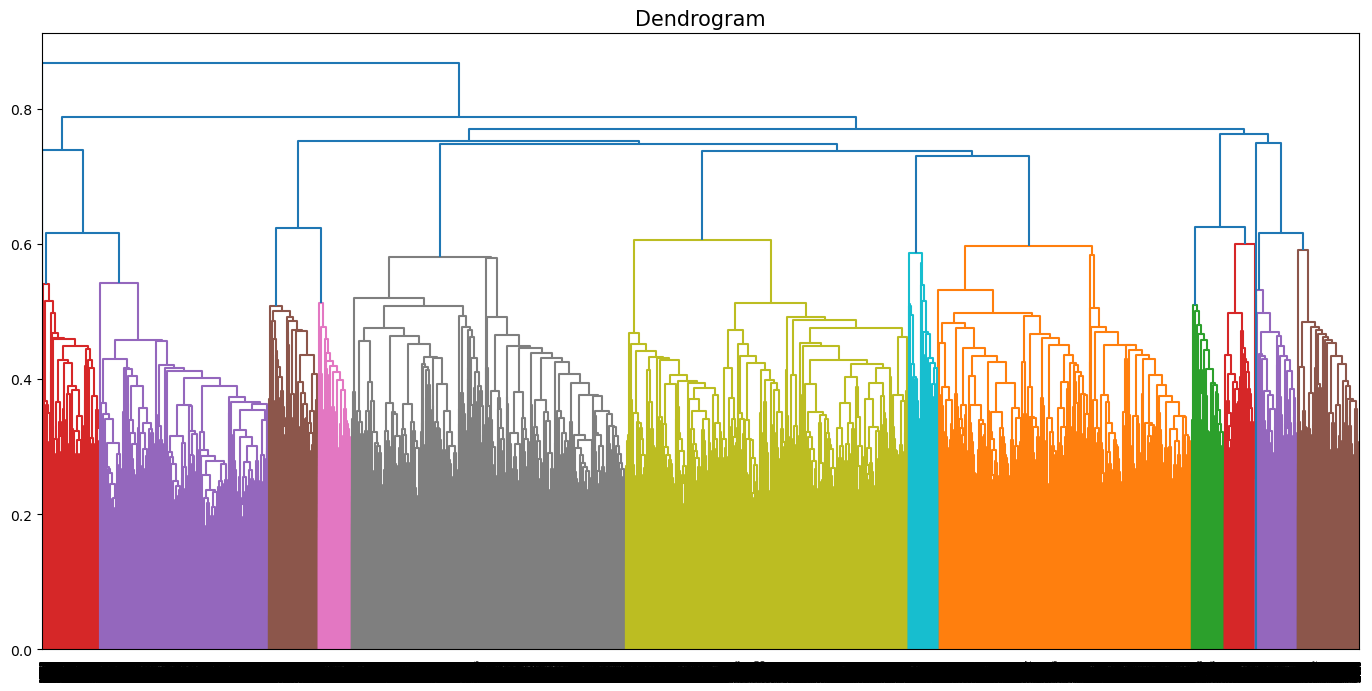

In [19]:
plt.figure(figsize = (17, 8))

# TODO: create dendogram using the "average" linkage method
# DOCUMENTATION: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
dendo = dendrogram(linkage(X1, method = 'average'))
plt.title('Dendrogram', fontsize = 15)
plt.xticks()
plt.show()

### Centroid Linkage Dendrogram

Creates clusters based the distance between cluster centroids.

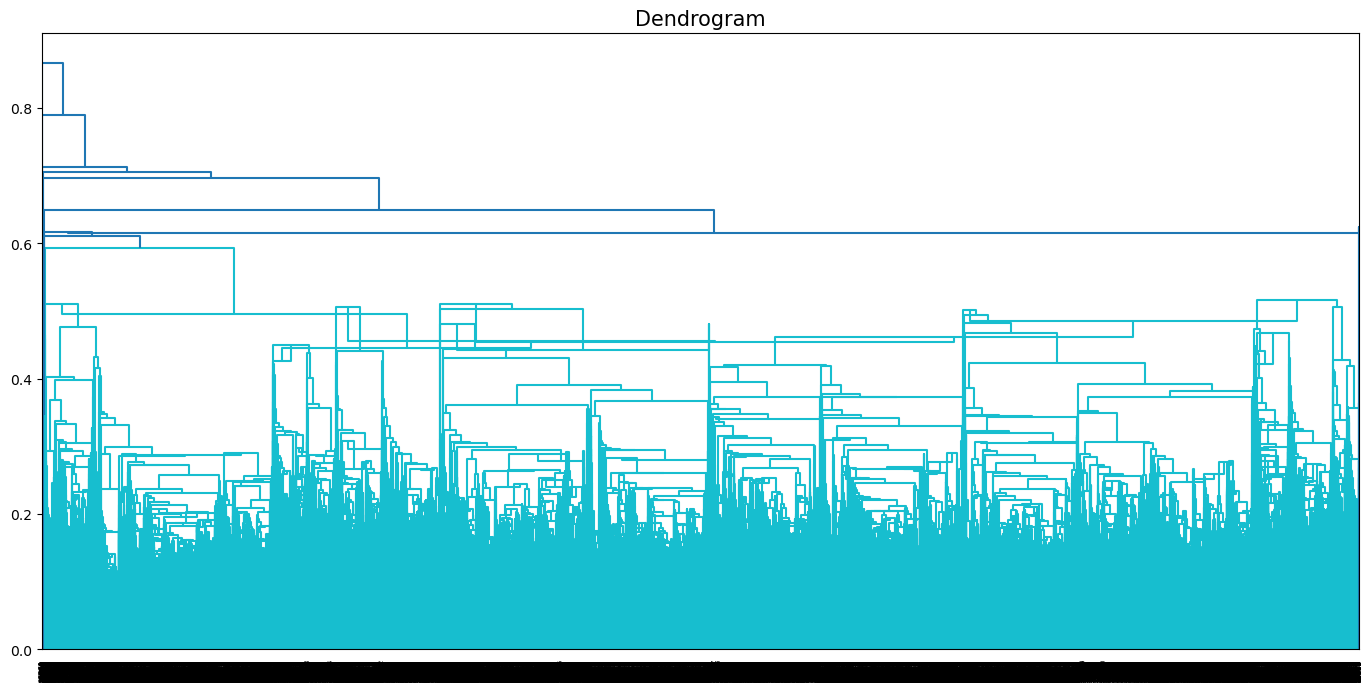

In [21]:
plt.figure(figsize = (17, 8))
dendo3 = dendrogram(linkage(X1, method = 'centroid'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

### Ward Linkage Dendrogram

Combines clusters based on average sum of squares distance between them. It seeks to minimize variance when combining clusters.

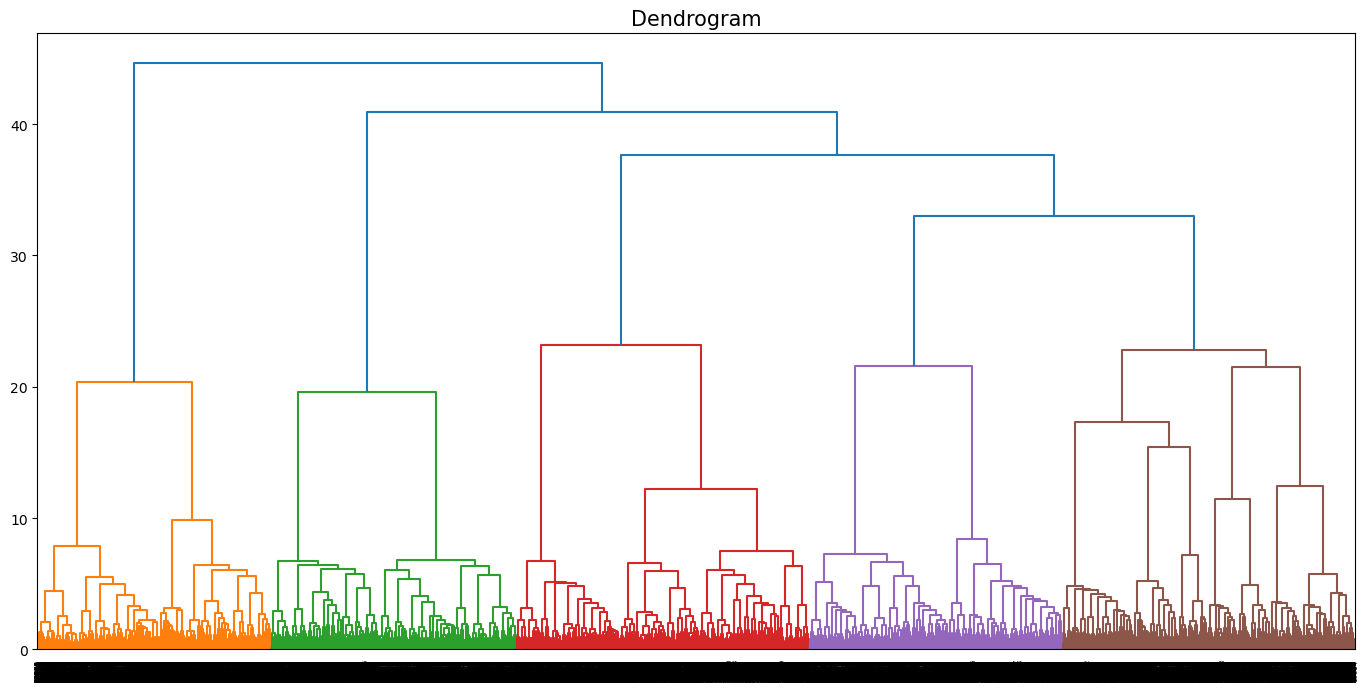

In [22]:
plt.figure(figsize = (17, 8))
dendo = dendrogram(linkage(X1, method = 'ward'))
plt.title('Dendrogram', fontsize = 15)
plt.show()

##### Out of all the models, the ward model seems to be the cleanest clustering of the data. While the graphic indicates 5 cluster is most optimal, I believe 10 is the optimal cut for our purposes.

In [96]:
agc = AgglomerativeClustering(n_clusters = 10, metric = 'euclidean', linkage = 'ward')
# fit and predict labels using `X1` dataset
ward_labels = agc.fit_predict(X1)
data['labels'] = ward_labels
#create labels for our full dataset 
data2['labels'] = ward_labels
data['labels'].value_counts()


labels
0    5282
4    4067
2    3135
7    2983
9    2642
8    2473
6    2397
5    2241
1    1801
3    1341
Name: count, dtype: int64

Similar amounts in all clusters bodes very well for this model.

In [63]:
#isolate each cluster for evaluation
cluster1 = data[data['labels'] == 0]
cluster2 = data[data['labels'] == 1]
cluster3 = data[data['labels'] == 2]
cluster4 = data[data['labels'] == 3]
cluster5 = data[data['labels'] == 4]
cluster6 = data[data['labels'] == 5]
cluster7 = data[data['labels'] == 6]
cluster8 = data[data['labels'] == 7]
cluster9 = data[data['labels'] == 8]
cluster10 = data[data['labels'] == 9]

labels
0    5282
4    4067
2    3135
7    2983
9    2642
8    2473
6    2397
5    2241
1    1801
3    1341
Name: count, dtype: int64

Now that we've seperated them all out, lets see how each column deviates from the mean for each cluster.

In [97]:
#save the label data and than drop labels in data because we already seperated by labels
label_data = data
label_data.to_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/HC_labels.csv')
data = data.drop(columns='labels')
#same for cluster1
cluster1 = cluster1.drop(columns='labels')
#distance from mean
c1 = cluster1.mean() - data.mean()
sns.barplot(c1)
plt.xticks(rotation=90)
plt.show()

KeyError: "['labels'] not found in axis"

## Cluster 1 is songs that are high in violence. 

#### Notably, these songs are not obsene or sad, and tend to be newer.

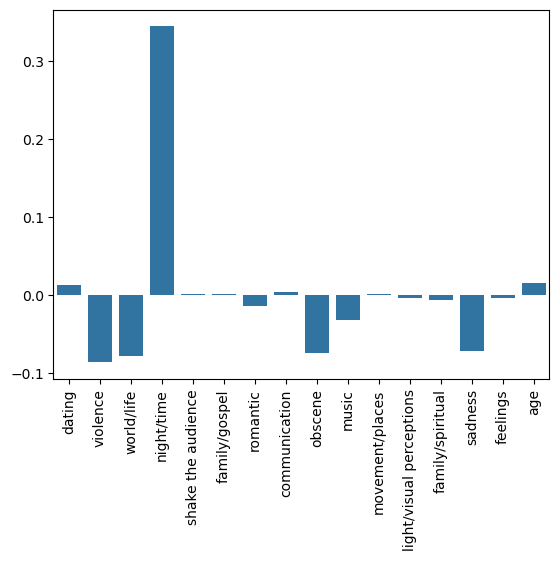

In [57]:
cluster2 = cluster2.drop(columns='labels')
c2 = cluster2.mean() - data.mean()
sns.barplot(c2)
plt.xticks(rotation=90)
plt.show()

## Cluster 2 is songs that are about night/time.   

#### These songs are not obsene or sad, but they are very non violent. Looking at our dendrogram, that is the key feature that splits these two clusters.

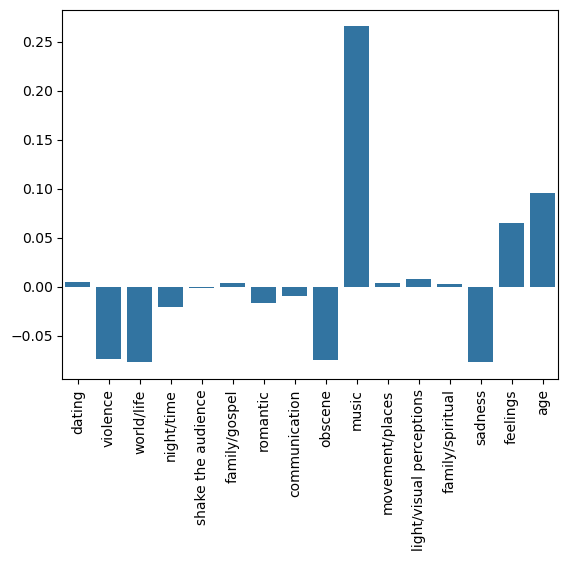

In [59]:
cluster3 = cluster3.drop(columns='labels')
c3 = cluster3.mean() - data.mean()
sns.barplot(c3)
plt.xticks(rotation=90)
plt.show()

## Cluster 3 is songs about music. 

#### These songs tend to be older and have content about feelings other than sadness. 

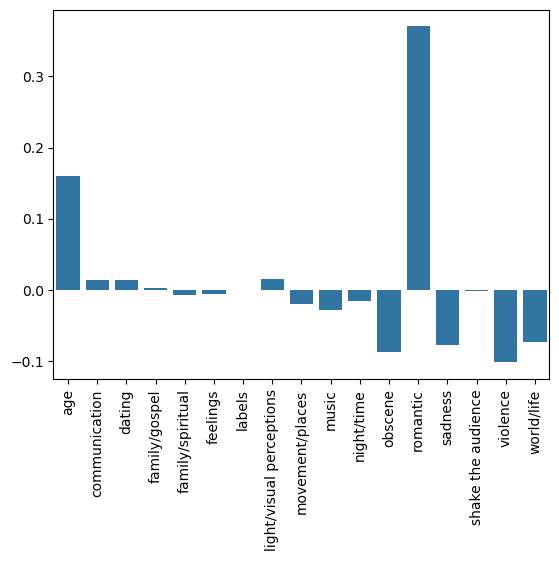

In [61]:
cluster4 = cluster4.drop(columns='labels')
c4 = cluster4.mean() - data.mean()
sns.barplot(c4)
plt.xticks(rotation=90)
plt.show()

## Cluster 4 is songs about romance. 

#### These songs are much older on average, but do not appear to sad songs either.

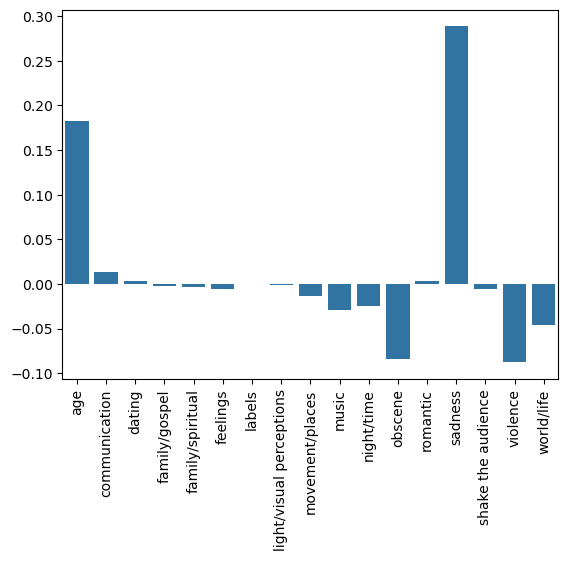

In [75]:
cluster5 = cluster5.drop(columns='labels')
c5 = cluster5.mean() - data.mean()
sns.barplot(c5)
plt.xticks(rotation=90)
plt.show()

## Cluster 5 are the sad, sad songs. 

#### These songs are much older on average, as well.

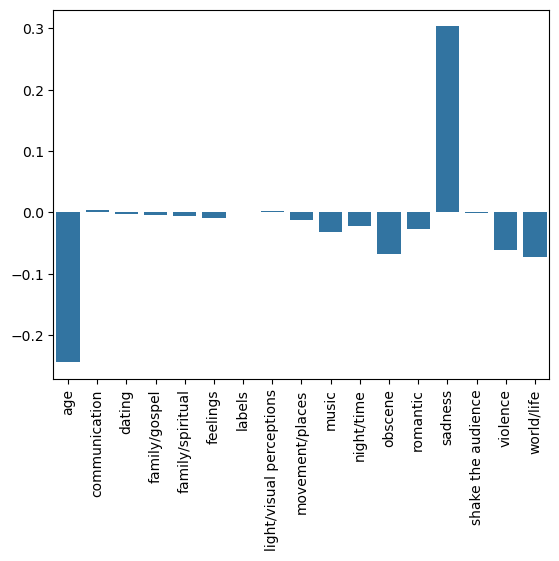

In [76]:
cluster6 = cluster6.drop(columns='labels')
c6 = cluster6.mean() - data.mean()
sns.barplot(c6)
plt.xticks(rotation=90)
plt.show()

## Cluster 6 are sad songs, too, but these songs are much younger on average.

#### I find this split very interesting, because much of the other data remained the same. It seems that there is a large enough difference between old and new sad songs to classify them sepereately.

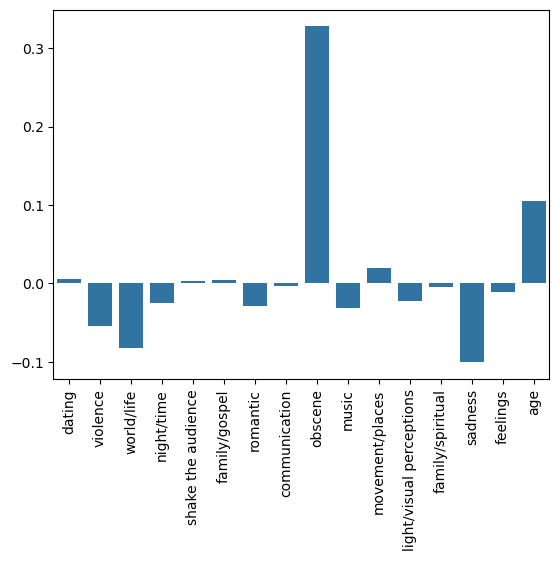

In [82]:
cluster7 = cluster7.drop(columns='labels')
c7 = cluster7.mean() - data.mean()
sns.barplot(c7)
plt.xticks(rotation=90)
plt.show()

## Cluster 7 is songs with high obsenity. 

#### These songs are older, given the  younger relative age of hip-hop this could very well be obsene songs not hip-hop

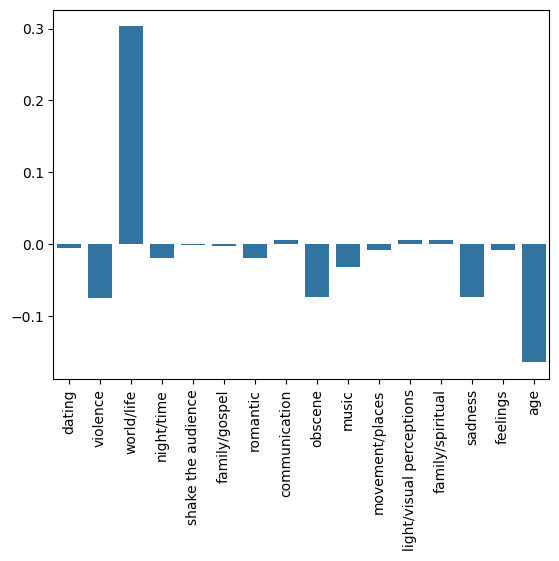

In [83]:
cluster8 = cluster8.drop(columns='labels')
c8 = cluster8.mean() - data.mean()
sns.barplot(c8)
plt.xticks(rotation=90)
plt.show()

## Cluster 8 is songs that reference the world/life. 

#### These songs tend to be younger, probably because the internet has made these topics much more contemperary.

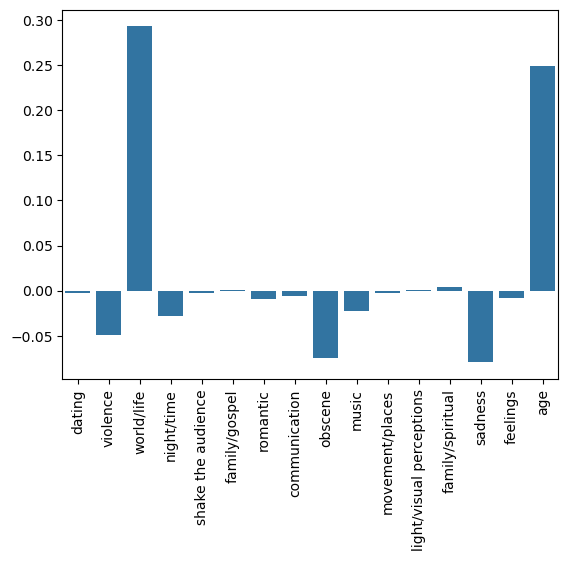

In [84]:
cluster9 = cluster9.drop(columns='labels')
c9 = cluster9.mean() - data.mean()
sns.barplot(c9)
plt.xticks(rotation=90)
plt.show()

## Cluster 9 is songs about world/life that skew far older. 

#### This is the second split based on age. 

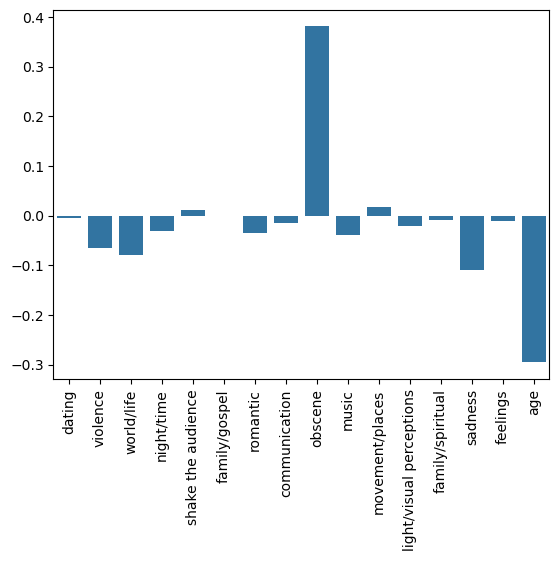

In [85]:
cluster10 = cluster10.drop(columns='labels')
c10 = cluster10.mean() - data.mean()
sns.barplot(c10)
plt.xticks(rotation=90)
plt.show()

## Cluster 10 is obsene songs that are much younger 

#### The young age and high obsenity means this is where hip-hop is likely clustered.

# Model Evaluation

##### Example of Function

In [93]:
data2 = data2[['artist_name', 'track_name', 'labels']]
sample = data2[data2['labels'] == 3]
sample.sample(5)

,artist_name,track_name,labels
986,percy sledge,warm and tender love,3
1184,fats domino,lovely rita,3
1201,van morrison,the way young lovers do,3
105,ricky nelson,true love,3
10662,the mavericks,i should have been true,3
